"""
Notebook 10

Final Model Selection
Industrial AI Pipeline

Author:
Hamid Saeli

Project

AI-based Anomaly Detection and Predictive Monitoring
for Industrial Water Treatment Systems
"""

In [1]:
from pathlib import Path

import joblib
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT/"data"/"processed"

MODEL_PATH = PROJECT_ROOT/"models"

RESULT_PATH = PROJECT_ROOT/"results"

MODEL_PATH.mkdir(exist_ok=True)

RESULT_PATH.mkdir(exist_ok=True)

In [3]:
train = pd.read_csv(DATA_PATH/"train_data.csv")

test = pd.read_csv(DATA_PATH/"test_data.csv")

X_train = train.drop(columns="Target")

y_train = train["Target"]

X_test = test.drop(columns="Target")

y_test = test["Target"]

In [4]:
best_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=15,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

best_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [5]:
pred = best_model.predict(X_test)

prob = best_model.predict_proba(X_test)[:,1]

In [6]:
metrics = {

    "Accuracy":

        accuracy_score(y_test,pred),

    "Precision":

        precision_score(y_test,pred),

    "Recall":

        recall_score(y_test,pred),

    "F1":

        f1_score(y_test,pred),

    "ROC AUC":

        roc_auc_score(y_test,prob)

}

metrics

{'Accuracy': 0.9991815331687152,
 'Precision': 0.9793684965913169,
 'Recall': 0.9994507506407909,
 'F1': 0.9893077201884741,
 'ROC AUC': 0.9999949890053776}

In [7]:
metric_df = pd.DataFrame(

    metrics,

    index=["Random Forest"]

)

metric_df.to_csv(

    RESULT_PATH/"model_metrics.csv"

)

In [8]:
report = classification_report(

    y_test,

    pred

)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277420
           1       0.98      1.00      0.99     10924

    accuracy                           1.00    288344
   macro avg       0.99      1.00      0.99    288344
weighted avg       1.00      1.00      1.00    288344



In [9]:
with open(

    RESULT_PATH/"classification_report.txt",

    "w"

) as f:

    f.write(report)

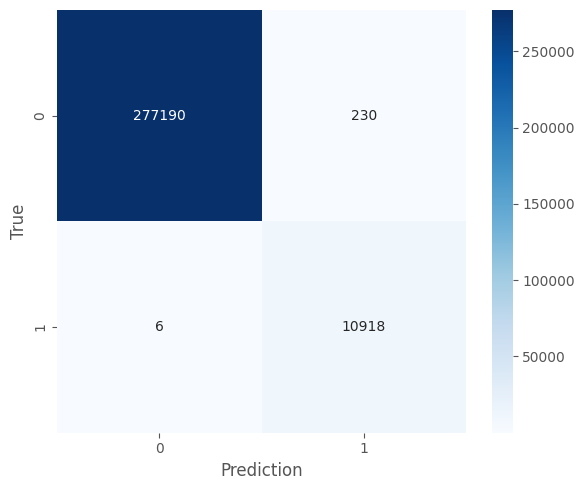

In [10]:
cm = confusion_matrix(

    y_test,

    pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Prediction")

plt.ylabel("True")

plt.tight_layout()

plt.savefig(

    RESULT_PATH/"confusion_matrix.png",

    dpi=300

)

plt.show()

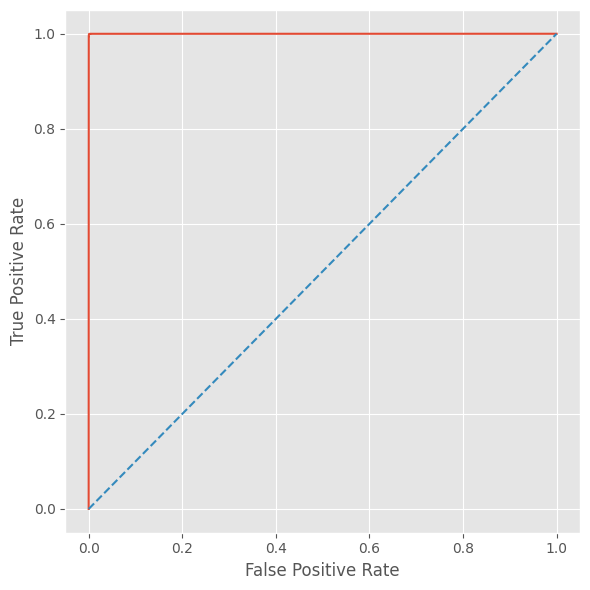

In [11]:
fpr,tpr,_ = roc_curve(

    y_test,

    prob

)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.tight_layout()

plt.savefig(

    RESULT_PATH/"roc_curve.png",

    dpi=300

)

plt.show()

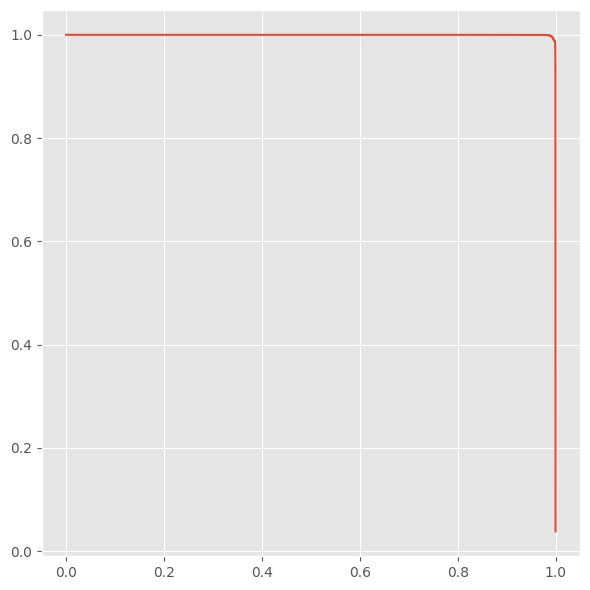

In [12]:
precision,recall,_ = precision_recall_curve(

    y_test,

    prob

)

plt.figure(figsize=(6,6))

plt.plot(

    recall,

    precision

)

plt.tight_layout()

plt.savefig(

    RESULT_PATH/"precision_recall_curve.png",

    dpi=300

)

plt.show()

In [13]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance.to_csv(

    RESULT_PATH/"feature_importance.csv",

    index=False

)

importance.head(20)

,Feature,Importance
37,AIT504,0.092455
46,PIT503,0.078230
44,PIT501,0.076546
26,AIT402,0.069275
34,AIT501,0.068840
5,AIT201,0.060016
45,PIT502,0.046413
27,FIT401,0.044140
40,FIT503,0.043962
35,AIT502,0.042372


In [14]:
prediction = X_test.copy()

prediction["True"] = y_test.values

prediction["Prediction"] = pred

prediction["Probability"] = prob

prediction.to_csv(

    RESULT_PATH/"predictions.csv",

    index=False

)

In [15]:
joblib.dump(

    best_model,

    MODEL_PATH/"best_model.pkl"

)

['E:\\new\\hamid\\CV\\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\\models\\best_model.pkl']

In [16]:
joblib.dump(

    list(X_train.columns),

    MODEL_PATH/"selected_features.pkl"

)

['E:\\new\\hamid\\CV\\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\\models\\selected_features.pkl']

In [17]:
threshold = 0.5

joblib.dump(

    threshold,

    MODEL_PATH/"decision_threshold.pkl"

)

['E:\\new\\hamid\\CV\\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\\models\\decision_threshold.pkl']

In [18]:
print("="*60)

print("Final Model Successfully Saved")

print("Model :",MODEL_PATH/"best_model.pkl")

print("Metrics :",RESULT_PATH/"model_metrics.csv")

print("Predictions :",RESULT_PATH/"predictions.csv")

print("="*60)

Final Model Successfully Saved
Model : E:\new\hamid\CV\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\models\best_model.pkl
Metrics : E:\new\hamid\CV\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\results\model_metrics.csv
Predictions : E:\new\hamid\CV\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\results\predictions.csv
